# Customer Analytics — Segmentation, Retention & Revenue

Exploratory analysis of the UCI Online Retail dataset using Python.  
This notebook covers four interconnected topics:

1. **Data Cleaning** — remove cancellations, invalid records, and missing customer IDs
2. **RFM Segmentation** — KMeans clustering on Recency, Frequency, and Monetary features
3. **Cohort Retention** — month-over-month retention heatmap by acquisition cohort
4. **Revenue Concentration** — Pareto analysis of customer revenue distribution

The RFM cluster labels are exported to `rfm_clusters.csv` for downstream SQL analysis.

## 1. Data Cleaning

Load the raw dataset and remove:
- Rows with missing `CustomerID`
- Cancelled orders (InvoiceNo starting with `C`)
- Transactions with non-positive `Quantity` or `UnitPrice`

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("online_retail.csv")

In [8]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df.shape

(541909, 8)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

---

## 2. RFM Segmentation

Compute three behavioral features per customer:

| Feature | Definition |
|---------|-----------|
| **Recency** | Days since last purchase (relative to dataset end date) |
| **Frequency** | Number of distinct orders |
| **Monetary** | Total spend (GBP) |

Features are standardized before clustering.

In [3]:
# remove rows with NaN CustomerID
df = df.dropna(subset=['CustomerID'])

#removed cancelled order. invoice No starts with 'C'
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

#remove Negative or Zero quantity and price 
df = df[(df['Quantity']>0) & (df['UnitPrice']>0)]

#convert InvoiceDate to datetime 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#create total_price column per transcation
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.shape

(397884, 9)

In [4]:
#reference date(last date in dataset)
reference_date = df['InvoiceDate'].max()+pd.Timedelta(days=1)

#create RFM table 
rfm = df.groupby("CustomerID").agg({
    #recency
    'InvoiceDate': lambda x:(reference_date - x.max()).days,
    #frequency
    'InvoiceNo':'nunique',
    #Monetary
    'TotalPrice':'sum'

})
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()



,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [5]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

### Dimensionality Reduction (PCA)

PCA is used to project customers into 2D for visualization. It is not used as input to KMeans — clustering is performed on the full 3-feature scaled space.

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

pca.explained_variance_ratio_

array([0.55502102, 0.30249315])

In [7]:
pca.components_

array([[-0.38055064,  0.67516736,  0.63192582],
       [ 0.9051887 ,  0.13211774,  0.40395336]])

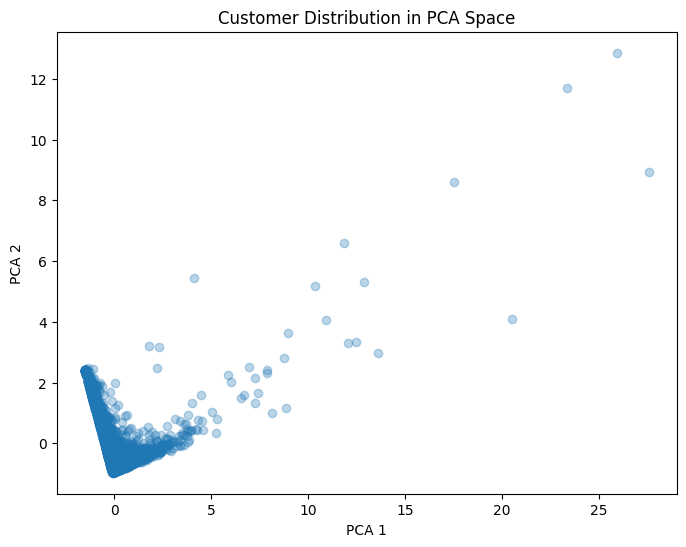

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], alpha=0.3)
plt.xlabel("PCA 1")
plt.ylabel('PCA 2')
plt.title('Customer Distribution in PCA Space')
plt.show()

### Choosing K (Elbow Method)

c:\Users\kangh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\kangh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\kangh\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kangh\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execut

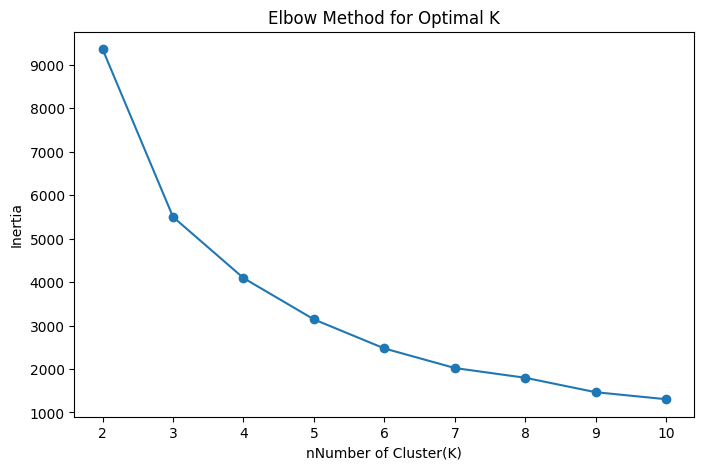

In [9]:
from sklearn.cluster import KMeans 

inertia = []

K_range = range(2,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('nNumber of Cluster(K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

K = 4 is selected — inertia decrease becomes gradual beyond this point.

### KMeans Clustering

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


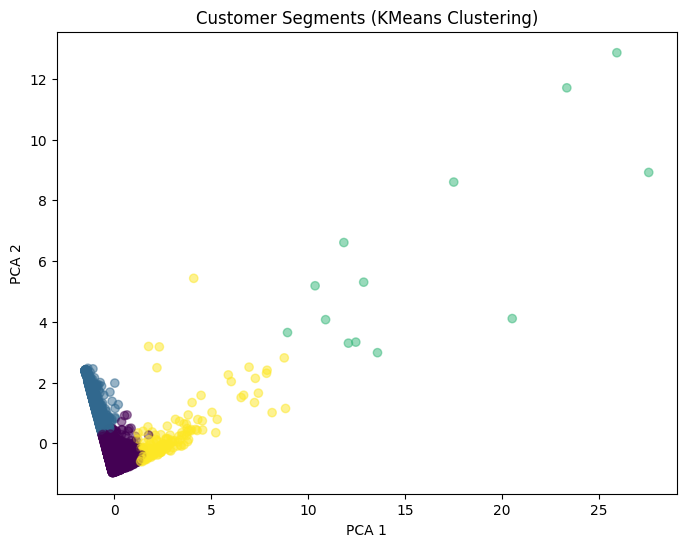

In [11]:
# plot clusters
plt.figure(figsize = (8,6))
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster'], cmap='viridis', alpha=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (KMeans Clustering)")
plt.show()

In [12]:
cluster_profile = rfm.groupby('Cluster').agg({'Recency':'mean', "Frequency":"mean", "Monetary":"mean", "Cluster": "count"}).rename(columns={"Cluster":"CustomerCount"})
cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.702685,3.682711,1359.049284,3054
1,248.075914,1.552015,480.617480,1067
2,7.384615,82.538462,127338.313846,13
3,15.500000,22.333333,12709.090490,204


### Cluster Profiles

| Cluster | Size | Profile | Description |
|---------|------|---------|-------------|
| 0 | ~3,000 | Regular customers | Moderate frequency and spend — the largest group, active but not highly engaged |
| 1 | ~1,000 | At-risk / lapsed | Low activity, long time since last purchase — clear churn risk |
| 2 | ~13 | Whales | Extremely high spend and frequency — likely bulk or B2B buyers |
| 3 | ~200 | High-value loyals | Frequent purchases, high spend — core revenue drivers |

**Key takeaway:** Customer behavior is not uniform. A small group (Cluster 2 + 3) drives disproportionate revenue, while the majority sit in low-to-moderate engagement tiers. Treating all customers the same is inefficient — each cluster calls for a distinct strategy.

### Export Cluster Labels

In [13]:
# Export cluster labels
# Reset index so CustomerID becomes a regular column
rfm_reset = rfm.reset_index()

# Export only required要的列
rfm_reset[['CustomerID', 'Cluster']].to_csv('rfm_clusters.csv', index=False)



---

## 3. Cohort Retention Analysis

Retention is defined as the percentage of customers from a given acquisition cohort who return to make a purchase in each subsequent month.

#### Build cohort month and cohort index

In [14]:
# Transaction month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# First purchase month per customer
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'] \
                      .transform('min') \
                      .dt.to_period('M')

In [15]:
def get_month_diff(d1, d2):
    return (d1.year - d2.year) * 12 + (d1.month - d2.month)

df['CohortIndex'] = df.apply(
    lambda x: get_month_diff(x['InvoiceMonth'], x['CohortMonth']),
    axis=1
)

In [16]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'] \
                .nunique() \
                .reset_index()

In [17]:
cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

In [18]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

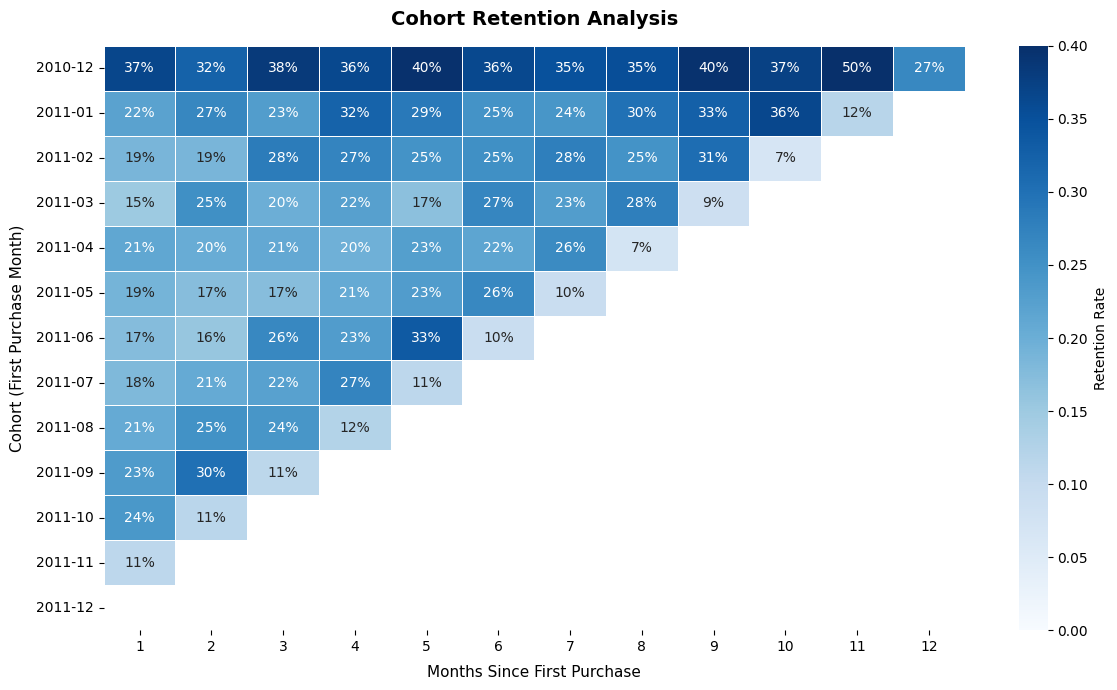

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = retention.iloc[:, 1:]

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    plot_data,
    ax=ax,
    cmap="Blues",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Retention Rate'},
    mask=plot_data.isnull(),
    vmin=0,
    vmax=0.4
)

ax.set_title('Cohort Retention Analysis', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=11, labelpad=8)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=11, labelpad=8)

plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
retention.round(3)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,0.095,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,0.095,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,0.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,0.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Findings

**Early drop-off is the dominant pattern.**  
Across all cohorts, Month 1 retention is 15–30%, meaning 70–85% of customers do not return after their first purchase. This is consistent with the funnel analysis in the SQL notebook.

**Churn is structural, not seasonal.**  
Retention patterns are stable across cohorts — no single time period stands out as unusually high or low. The drop-off is a persistent behavioral characteristic, not an anomaly.

**Customers return intermittently, not consistently.**  
Retention does not strictly decrease month over month. Several cohorts show a recovery in later months (e.g., Month 3 > Month 2), confirming that customers purchase occasionally rather than on a regular cycle.

> **Business implication:** The highest-leverage intervention point is converting first-time buyers into second-time buyers. Improving the 1→2 transition — rather than focusing on acquisition — is where retention effort should be concentrated.

---

## 4. Revenue Concentration (Pareto Analysis)

### Business Question

Is revenue evenly distributed across customers, or does a small group drive the majority of business value?

Understanding concentration helps prioritize retention and upsell efforts — if a small segment drives most revenue, protecting that segment is more valuable than acquiring new low-value customers.

### Step 1 — Rank customers by total spend

In [42]:
rfm_sorted = rfm.sort_values(by="Monetary", ascending=False)

In [44]:
rfm_sorted["cum_revenue_pct"] = rfm_sorted["Monetary"].cumsum() / rfm_sorted["Monetary"].sum()
rfm_sorted["cum_customer_pct"] = range(1, len(rfm_sorted)+1)
rfm_sorted["cum_customer_pct"] = rfm_sorted["cum_customer_pct"] / len(rfm_sorted)

### Step 2 — Identify the 80% revenue threshold

In [45]:
top_80 = rfm_sorted[rfm_sorted["cum_revenue_pct"] <= 0.8]
top_80.shape[0] / rfm.shape[0]

0.26094974642692487

### Step 3 — Visualize the Pareto curve

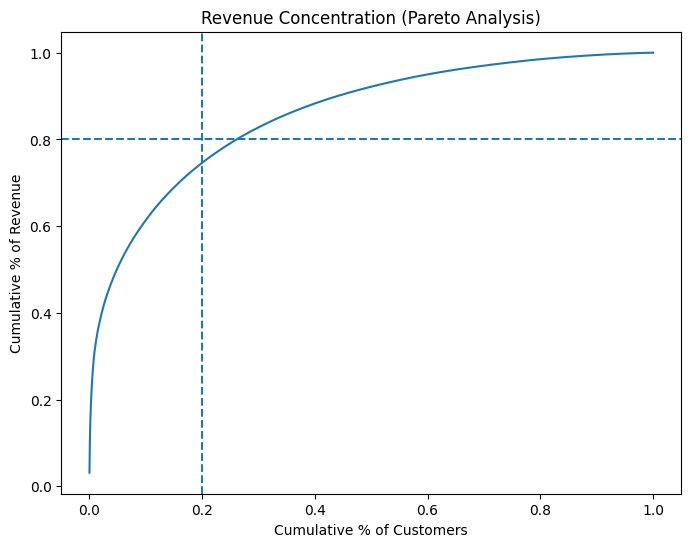

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(rfm_sorted["cum_customer_pct"], rfm_sorted["cum_revenue_pct"])

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")
plt.title("Revenue Concentration (Pareto Analysis)")

plt.axhline(y=0.8, linestyle='--')
plt.axvline(x=0.2, linestyle='--')

plt.show()

### Findings

Approximately **26% of customers contribute 80% of total revenue** — more dispersed than the classic 80/20 rule, but still a clear concentration.

Key implications:

- **Clusters 2 & 3** (whales + high-value loyals) map closely onto this top 26% — retaining them is the highest-priority task
- **The mid-tier is a real opportunity.** A 26% threshold (vs. the classic 10–20%) means there is a broad, upgradable segment — not just a tiny elite driving everything
- **Acquisition-only growth is inefficient.** Customers likely to churn after one purchase dilute the base; retention and upsell have higher ROI

> Cluster 2 likely represents B2B or wholesale accounts rather than typical retail customers. See sensitivity analysis below.

### Sensitivity Analysis — Excluding B2B Accounts (Cluster 2)

Cluster 2 (~13 customers) shows purchasing volume far outside the retail norm — likely wholesale or B2B buyers. Including them in the Pareto analysis may overstate revenue concentration for the retail base.

Re-running the analysis on retail-only customers (Clusters 0, 1, 3) to test robustness:

In [21]:
# Sensitivity Analysis — Excluding B2B Accounts (Cluster 2)
# Cluster 2 (~13 customers) shows extreme purchasing volume inconsistent
# with typical retail behavior, likely representing wholesale/B2B accounts.
# Re-running Pareto analysis on the remaining customer base to validate findings.

rfm_retail = rfm[rfm['Cluster'] != 2].copy()
rfm_retail_sorted = rfm_retail.sort_values(by="Monetary", ascending=False)
rfm_retail_sorted["cum_revenue_pct"] = (
    rfm_retail_sorted["Monetary"].cumsum() / rfm_retail_sorted["Monetary"].sum()
)

top_80_retail = rfm_retail_sorted[rfm_retail_sorted["cum_revenue_pct"] <= 0.8]
pct_retail = top_80_retail.shape[0] / rfm_retail_sorted.shape[0]

print(f"Excluding Cluster 2: top {pct_retail:.1%} of customers contribute 80% of revenue")
print(f"Compare: including all customers, top 26% drove 80% of revenue")

Excluding Cluster 2: top 31.2% of customers contribute 80% of revenue
Compare: including all customers, top 26% drove 80% of revenue


### Sensitivity Finding

Excluding B2B accounts, the top **31.2%** of retail customers contribute 80% of revenue — slightly more dispersed than the 26% all-customer figure.

| Scope | Top X% drives 80% revenue |
|-------|--------------------------|
| All customers (incl. Cluster 2) | 26% |
| Retail only (excl. Cluster 2) | 31.2% |

**Interpretation:** Cluster 2 inflates the concentration metric, but does not change the strategic conclusion. The retail mid-tier is even broader than the headline number suggests — making it a more scalable growth target than the 26% figure implies.

---

## Summary

The four analyses tell a consistent story:

1. **Segmentation** reveals that customers are not uniform — a small high-value tier (Clusters 2 & 3) drives most revenue, while the majority sit in low-engagement tiers
2. **Cohort retention** confirms that 70–85% of customers do not return after Month 0, and the drop-off is structural rather than seasonal
3. **Revenue concentration** shows ~26% of customers account for 80% of revenue, with a meaningful mid-tier that is upgradable
4. **The common thread:** the 1→2 purchase transition is the single highest-leverage point in the customer lifecycle

These findings are carried into a companion SQL analysis (`sql_business_analysis.ipynb`), which quantifies the funnel drop-off, validates the inter-purchase gap, and identifies Cluster 3 as the optimal target for a 45-day re-engagement coupon.



In [ ]:
# check if file exist 
import os
print(os.path.exists('rfm_clusters.csv'))  

True


## 5. Data Export for Tableau

Export cleaned datasets for dashboard visualisation in Tableau Public.

In [ ]:
# cohort retention change to long format
retention_long = retention.reset_index()
retention_long = retention_long.melt(
    id_vars='CohortMonth',
    var_name='MonthIndex',
    value_name='RetentionRate'
)
retention_long['MonthIndex'] = retention_long['MonthIndex'].astype(int)
retention_long.to_csv('cohort_retention.csv', index=False)
print(retention_long.dtypes)
print(retention_long.head(20))
print(f"Shape: {retention_long.shape}")

CohortMonth      period[M]
MonthIndex           int64
RetentionRate      float64
dtype: object
   CohortMonth  MonthIndex  RetentionRate
0      2010-12           0       1.000000
1      2011-01           0       1.000000
2      2011-02           0       1.000000
3      2011-03           0       1.000000
4      2011-04           0       1.000000
5      2011-05           0       1.000000
6      2011-06           0       1.000000
7      2011-07           0       1.000000
8      2011-08           0       1.000000
9      2011-09           0       1.000000
10     2011-10           0       1.000000
11     2011-11           0       1.000000
12     2011-12           0       1.000000
13     2010-12           1       0.366102
14     2011-01           1       0.220624
15     2011-02           1       0.186842
16     2011-03           1       0.150442
17     2011-04           1       0.213333
18     2011-05           1       0.190141
19     2011-06           1       0.173554
Shape: (169, 3)


In [26]:
print(retention_long.dtypes)
print(retention_long['MonthIndex'].unique())

CohortMonth       object
MonthIndex        object
RetentionRate    float64
dtype: object
[0 1 2 3 4 5 6 7 8 9 10 11 12]


In [ ]:
# Including B2B and exlcuding 
rfm_sorted_full = rfm.sort_values('Monetary', ascending=False).reset_index()
rfm_sorted_full['cum_revenue_pct'] = rfm_sorted_full['Monetary'].cumsum() / rfm_sorted_full['Monetary'].sum()
rfm_sorted_full['cum_customer_pct'] = (rfm_sorted_full.index + 1) / len(rfm_sorted_full)
rfm_sorted_full['include_b2b'] = 'Including B2B'

rfm_no_b2b_sorted2 = rfm[rfm['Cluster'] != 2].sort_values('Monetary', ascending=False).reset_index()
rfm_no_b2b_sorted2['cum_revenue_pct'] = rfm_no_b2b_sorted2['Monetary'].cumsum() / rfm_no_b2b_sorted2['Monetary'].sum()
rfm_no_b2b_sorted2['cum_customer_pct'] = (rfm_no_b2b_sorted2.index + 1) / len(rfm_no_b2b_sorted2)
rfm_no_b2b_sorted2['include_b2b'] = 'Excluding B2B'

pareto_data = pd.concat([rfm_sorted_full, rfm_no_b2b_sorted2], ignore_index=True)
pareto_data[['CustomerID','Monetary','Cluster','cum_revenue_pct','cum_customer_pct','include_b2b']].to_csv('pareto_data.csv', index=False)
print(pareto_data.shape)

(8663, 8)
